## RUN1
N = 10              
K = 2                
B = 100              
SIGMA_U = 1.0       
TAU = 0.1            
LAMBDA_GRID = [0.0, 0.1, 1.0, 5.0, 10.0, 50.0] 

NUM_SAMPLES = 100    
WARMUP_STEPS = 50    
NUM_CHAINS = 2

In [15]:
import sys
import itertools
import torch
import pyro
import pyro.infer as infer
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
sys.path.append(os.path.abspath(".."))
from src.model import PhylogeneticPrior
from src.penalty import get_fresh_test_quartets
from src.diagnostics import evaluate_test_diagnostics, print_diagnostic_report



STARTING EXPERIMENT 1 SWEEP (N = 50, B = 3000)
 -> Penalty Set Size   : 3000 quartets
 -> Held-Out Test Pool : 1000 fresh quartets

Running Lambda = 0.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [00:07, 79.72it/s, step size=4.21e-01, acc. prob=0.880] 


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [00:06, 89.83it/s, step size=4.27e-01, acc. prob=0.864] 


Running Lambda = 1.0...
  └── Sampling Chain 1/2...


...

Running Lambda = 100.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [01:42,  5.84it/s, step size=8.25e-02, acc. prob=0.855]


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [01:37,  6.13it/s, step size=9.63e-02, acc. prob=0.822]



Lambda     | Mean Bulk ESS   | Max R-hat    | Divergences
0.0        | 1682.5          | 1.0200       | 0         
1.0        | 1227.8          | 1.0100       | 0         
10.0       | 907.9           | 1.0200       | 0         
25.0       | 1218.5          | 1.0200       | 0         
100.0      | 916.8           | 1.0300       | 0         


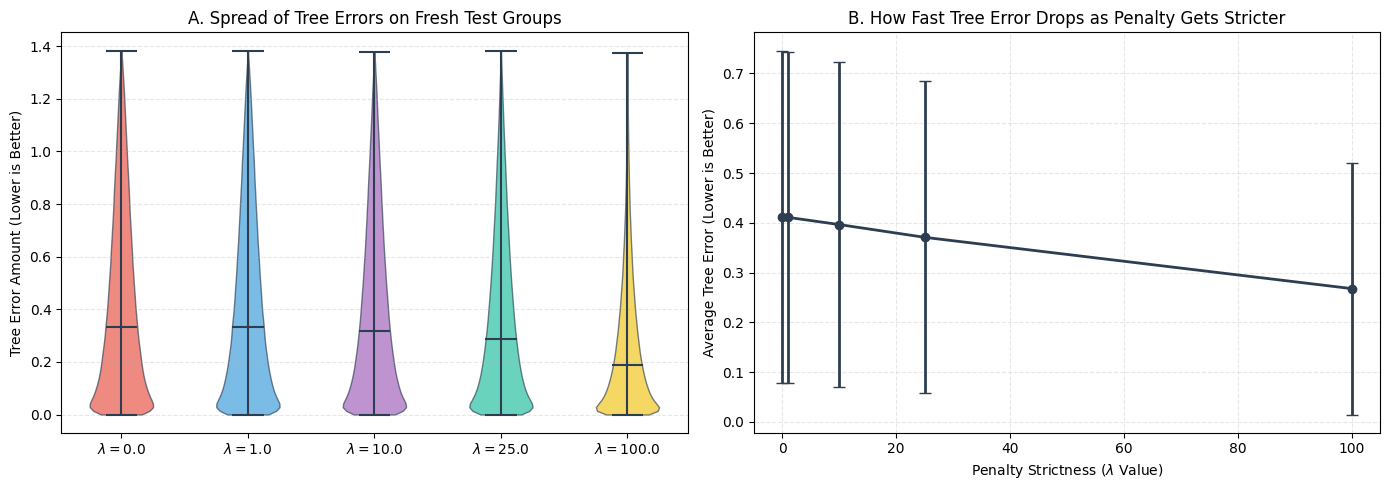

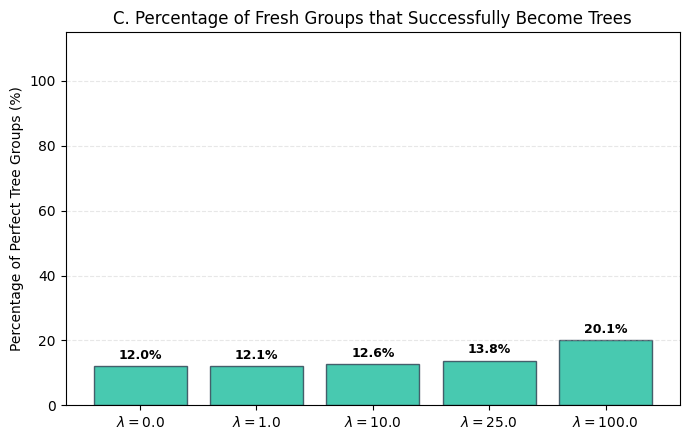

In [29]:
import sys
import torch
import pyro
import pyro.infer as infer
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# Connect your local src framework modules directly
from src.model import PhylogeneticPrior
from src.penalty import get_fresh_test_quartets

# =====================================================================
# 1. EXPERIMENT PARAMETERS (CHANGE THESE FOR RUN 1 VS RUN 2)
# =====================================================================
N = 50        # Number of leaves (Use 10 for Run 2, use 50 for Run 1)
K = 2         # Hyperbolic dimensions
B = 3000      # Training quartets budget (Use 100 for N=10, 3000 for N=50)
B_TEST = 1000 # Test quartets budget (Use 100 for N=10, 1000 for N=50)

SIGMA_U = 1.0 # Base Gaussian prior scale
TAU = 0.02    # Smoothness temperature (Use 0.1 for N=10, 0.02 for N=50)
LAMBDA_GRID = [0.0, 1.0, 10.0, 25.0, 100.0] # Your custom experiment 1 grid

# MCMC Sampler Settings
NUM_SAMPLES = 400    # Number of posterior draws
WARMUP_STEPS = 200   # Number of warmup iterations
NUM_CHAINS = 2       # Run 2 independent chains sequentially

# Initialize your project model workspace geometry globally
model_instance = PhylogeneticPrior(N=N, K=K, B=B, seed=42)

if __name__ == "__main__":
    saved_samples = {}
    mcmc_reports = {}

    # Isolate our fresh test set using your clean O(1) tuple-matching function
    test_quartets = get_fresh_test_quartets(
        N=N, 
        B_test=B_TEST, 
        train_quartets=model_instance.fixed_indices,
        seed=123
    )

    print("="*60)
    print(f"STARTING EXPERIMENT 1 SWEEP (N = {N}, B = {B})")
    print(f" -> Penalty Set Size   : {B} quartets")
    print(f" -> Held-Out Test Pool : {len(test_quartets)} fresh quartets")
    print("="*60 + "\n")

    # =====================================================================
    # 2. SEQUENTIAL MCMC SAMPLING SWEEP
    # =====================================================================
    for lmbda in LAMBDA_GRID:
        print(f"Running Lambda = {lmbda}...")
        
        chain_samples = []
        chain_diagnostics = []
        
        # Run independent chains sequentially to dodge background OS traps
        for chain_id in range(NUM_CHAINS):
            print(f"  └── Sampling Chain {chain_id + 1}/{NUM_CHAINS}...")
            pyro.clear_param_store()
            pyro.set_rng_seed(42 + chain_id)
            
            def target_model():
                return model_instance.initialize(lmbda=lmbda, sigma_u=SIGMA_U, tau=TAU)

            nuts_kernel = infer.NUTS(target_model, target_accept_prob=0.8)
            mcmc = infer.MCMC(
                nuts_kernel, 
                num_samples=NUM_SAMPLES, 
                warmup_steps=WARMUP_STEPS, 
                num_chains=1
            )
            mcmc.run()
            
            chain_samples.append(mcmc.get_samples())
            chain_diagnostics.append(mcmc.diagnostics())
        
        # Combine 'u' samples across a new chain axis for ArviZ tracking structures
        combined_u = torch.stack([cs["u"] for cs in chain_samples], dim=0)
        
        # Flatten samples to re-generate distance matrices 'D' via Predictive distribution
        pooled_samples = {"u": combined_u.view(-1, N, K)}
        predictive = infer.Predictive(target_model, posterior_samples=pooled_samples)
        saved_samples[lmbda] = predictive()["D"].squeeze().clone()
        
        # Sum total chain divergences explicitly
        total_div = 0
        for diag in chain_diagnostics:
            total_div += sum(len(d) if isinstance(d, list) else int(d) for d in diag.get("diverging", {}).values())
        
        # Extract Sampler Health metrics via ArviZ
        az_data = az.from_dict(posterior={"u": combined_u})
        summary_stats = az.summary(az_data)
        
        mcmc_reports[lmbda] = {
            "ess": summary_stats["ess_bulk"].mean(),
            "rhat": summary_stats["r_hat"].max(),
            "div": total_div
        }

    # =====================================================================
    # 3. PRINT SAMPLER HEALTH DASHBOARD REPORT
    # =====================================================================
    print("\n" + "="*55)
    print(f"{'Lambda':<10} | {'Mean Bulk ESS':<15} | {'Max R-hat':<12} | {'Divergences':<10}")
    print("="*55)
    for lmbda in LAMBDA_GRID:
        m = mcmc_reports[lmbda]
        print(f"{lmbda:<10} | {m['ess']:<15.1f} | {m['rhat']:<12.4f} | {m['div']:<10}")
    print("="*55)

    # =====================================================================
    # 4. CALCULATE GEOMETRIC VIOLATIONS ON THE TEST SET
    # =====================================================================
    all_violations = []
    line_means = []
    line_stds = []

    # Separate test quartet indices into distinct a, b, c, d coordinate vectors
    a = test_quartets[:, 0]
    b = test_quartets[:, 1]
    c = test_quartets[:, 2]
    d = test_quartets[:, 3]

    for lmbda in LAMBDA_GRID:
        D_batch = saved_samples[lmbda]
        
        # Pull the pairwise distance coordinates out of the generated matrices
        s1 = D_batch[:, a, b] + D_batch[:, c, d]
        s2 = D_batch[:, a, c] + D_batch[:, b, d]
        s3 = D_batch[:, a, d] + D_batch[:, b, c]
        
        # Sort them along the last axis to isolate s_(1) <= s_(2) <= s_(3)
        s_sorted, _ = torch.sort(torch.stack([s1, s2, s3], dim=-1), dim=-1)
        
        # Hard Four-Point Violation = s_(3) - s_(2)
        v_q = (s_sorted[..., 2] - s_sorted[..., 1]).flatten().numpy()
        
        all_violations.append(v_q)
        line_means.append(np.mean(v_q))
        line_stds.append(np.std(v_q))

    # =====================================================================
    # 5. RENDER DIAGNOSTIC PLOTS A & B (DUAL PANEL PANEL)
    # =====================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    positions = list(range(1, len(LAMBDA_GRID) + 1))

    # --- PLOT A: Colored Violin Profiles ---
    violin_parts = ax1.violinplot(all_violations, positions, showmedians=True)
    
    # Bright, distinctive color palette assignments for your grid scales
    colors = ['#E74C3C', '#3498DB', '#9B59B6', '#1ABC9C', '#F1C40F', '#2ECC71', '#E67E22']
    for idx, body in enumerate(violin_parts['bodies']):
        body.set_facecolor(colors[idx % len(colors)])
        body.set_alpha(0.65)           
        body.set_edgecolor('#2C3E50')  

    for part in ['cmaxes', 'cmins', 'cbars', 'cmedians']:
        if part in violin_parts:
            violin_parts[part].set_edgecolor('#2C3E50')
            violin_parts[part].set_linewidth(1.5)

    ax1.set_xticks(positions)
    ax1.set_xticklabels([f"$\lambda = {l}$" for l in LAMBDA_GRID])
    ax1.set_ylabel('Tree Error Amount (Lower is Better)')
    ax1.set_title('A. Spread of Tree Errors on Fresh Test Groups')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # --- PLOT B: Clean Decay Curve ---
    ax2.errorbar(LAMBDA_GRID, line_means, yerr=line_stds, fmt='-o', color='#2C3E50', capsize=4, linewidth=2)
    ax2.set_xlabel('Penalty Strictness ($\lambda$ Value)')
    ax2.set_ylabel('Average Tree Error (Lower is Better)')
    ax2.set_title('B. How Fast Tree Error Drops as Penalty Gets Stricter')
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =====================================================================
    # 6. RENDER PLOT C: TREE-CONSISTENCY RATE (BAR CHART)
    # =====================================================================
    epsilon = 0.05
    consistency_rates = [np.mean((violations <= epsilon).astype(float)) * 100 for violations in all_violations]

    fig, ax3 = plt.subplots(figsize=(7, 4.5))
    bars = ax3.bar([f"$\lambda = {l}$" for l in LAMBDA_GRID], consistency_rates, color='#1ABC9C', edgecolor='#2C3E50', alpha=0.8)

    # Put direct text percentages right on top of each bar so it's super easy to read
    for bar in bars:
        height = bar.get_height()
        ax3.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax3.set_ylabel('Percentage of Perfect Tree Groups (%)')
    ax3.set_title('C. Percentage of Fresh Groups that Successfully Become Trees')
    ax3.set_ylim(0, 115) 
    ax3.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

STARTING EXPERIMENT 1 SWEEP (N = 50, B = 3000)
 -> Penalty Set Size   : 3000 quartets
 -> Held-Out Test Pool : 1000 fresh quartets

Running Lambda = 0.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [00:06, 95.38it/s, step size=4.21e-01, acc. prob=0.880] 


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [00:05, 109.82it/s, step size=4.27e-01, acc. prob=0.864]


Running Lambda = 1.0...
  └── Sampling Chain 1/2...


...

Running Lambda = 100.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [01:48,  5.55it/s, step size=6.94e-02, acc. prob=0.841]


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [01:54,  5.23it/s, step size=7.15e-02, acc. prob=0.832]



Lambda     | Mean Bulk ESS   | Max R-hat    | Divergences
0.0        | 1682.5          | 1.0200       | 0         
1.0        | 1302.7          | 1.0200       | 0         
10.0       | 716.4           | 1.0300       | 0         
25.0       | 971.7           | 1.0200       | 0         
100.0      | 672.8           | 1.0300       | 0         


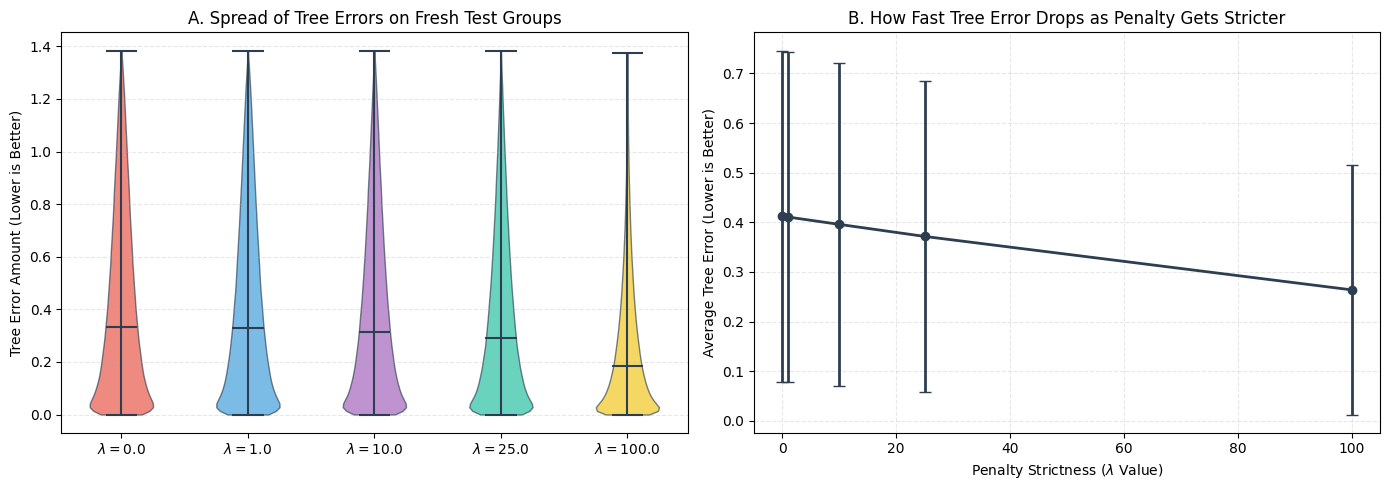

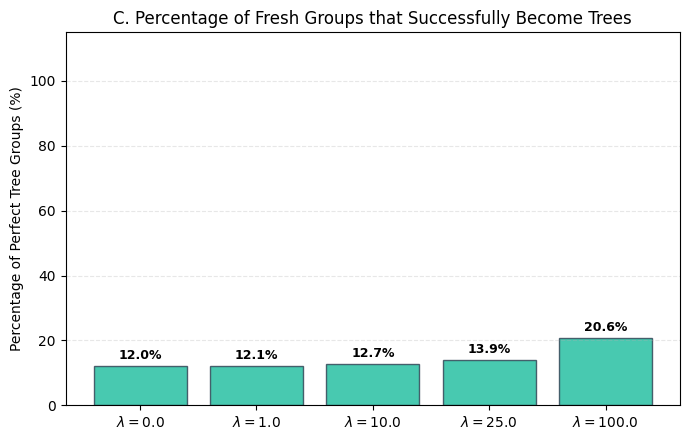

In [31]:
import sys
import torch
import pyro
import pyro.infer as infer
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# Connect your local src framework modules directly
from src.model import PhylogeneticPrior
from src.penalty import get_fresh_test_quartets

# =====================================================================
# 1. EXPERIMENT PARAMETERS (CHANGE THESE FOR RUN 1 VS RUN 2)
# =====================================================================
N = 50        # Number of leaves (Use 10 for Run 2, use 50 for Run 1)
K = 2         # Hyperbolic dimensions
B = 3000      # Training quartets budget (Use 100 for N=10, 3000 for N=50)
B_TEST = 1000 # Test quartets budget (Use 100 for N=10, 1000 for N=50)

SIGMA_U = 1.0 # Base Gaussian prior scale
TAU = 0.005   # Smoothness temperature (Use 0.1 for N=10, 0.02 for N=50)
LAMBDA_GRID = [0.0, 1.0, 10.0, 25.0, 100.0] # Your custom experiment 1 grid

# MCMC Sampler Settings
NUM_SAMPLES = 400    # Number of posterior draws
WARMUP_STEPS = 200   # Number of warmup iterations
NUM_CHAINS = 2       # Run 2 independent chains sequentially

# Initialize your project model workspace geometry globally
model_instance = PhylogeneticPrior(N=N, K=K, B=B, seed=42)

if __name__ == "__main__":
    saved_samples = {}
    mcmc_reports = {}

    # Isolate our fresh test set using your clean O(1) tuple-matching function
    test_quartets = get_fresh_test_quartets(
        N=N, 
        B_test=B_TEST, 
        train_quartets=model_instance.fixed_indices,
        seed=123
    )

    print("="*60)
    print(f"STARTING EXPERIMENT 1 SWEEP (N = {N}, B = {B})")
    print(f" -> Penalty Set Size   : {B} quartets")
    print(f" -> Held-Out Test Pool : {len(test_quartets)} fresh quartets")
    print("="*60 + "\n")

    # =====================================================================
    # 2. SEQUENTIAL MCMC SAMPLING SWEEP
    # =====================================================================
    for lmbda in LAMBDA_GRID:
        print(f"Running Lambda = {lmbda}...")
        
        chain_samples = []
        chain_diagnostics = []
        
        # Run independent chains sequentially to dodge background OS traps
        for chain_id in range(NUM_CHAINS):
            print(f"  └── Sampling Chain {chain_id + 1}/{NUM_CHAINS}...")
            pyro.clear_param_store()
            pyro.set_rng_seed(42 + chain_id)
            
            def target_model():
                return model_instance.initialize(lmbda=lmbda, sigma_u=SIGMA_U, tau=TAU)

            nuts_kernel = infer.NUTS(target_model, target_accept_prob=0.8)
            mcmc = infer.MCMC(
                nuts_kernel, 
                num_samples=NUM_SAMPLES, 
                warmup_steps=WARMUP_STEPS, 
                num_chains=1
            )
            mcmc.run()
            
            chain_samples.append(mcmc.get_samples())
            chain_diagnostics.append(mcmc.diagnostics())
        
        # Combine 'u' samples across a new chain axis for ArviZ tracking structures
        combined_u = torch.stack([cs["u"] for cs in chain_samples], dim=0)
        
        # Flatten samples to re-generate distance matrices 'D' via Predictive distribution
        pooled_samples = {"u": combined_u.view(-1, N, K)}
        predictive = infer.Predictive(target_model, posterior_samples=pooled_samples)
        saved_samples[lmbda] = predictive()["D"].squeeze().clone()
        
        # Sum total chain divergences explicitly
        total_div = 0
        for diag in chain_diagnostics:
            total_div += sum(len(d) if isinstance(d, list) else int(d) for d in diag.get("diverging", {}).values())
        
        # Extract Sampler Health metrics via ArviZ
        az_data = az.from_dict(posterior={"u": combined_u})
        summary_stats = az.summary(az_data)
        
        mcmc_reports[lmbda] = {
            "ess": summary_stats["ess_bulk"].mean(),
            "rhat": summary_stats["r_hat"].max(),
            "div": total_div
        }

    # =====================================================================
    # 3. PRINT SAMPLER HEALTH DASHBOARD REPORT
    # =====================================================================
    print("\n" + "="*55)
    print(f"{'Lambda':<10} | {'Mean Bulk ESS':<15} | {'Max R-hat':<12} | {'Divergences':<10}")
    print("="*55)
    for lmbda in LAMBDA_GRID:
        m = mcmc_reports[lmbda]
        print(f"{lmbda:<10} | {m['ess']:<15.1f} | {m['rhat']:<12.4f} | {m['div']:<10}")
    print("="*55)

    # =====================================================================
    # 4. CALCULATE GEOMETRIC VIOLATIONS ON THE TEST SET
    # =====================================================================
    all_violations = []
    line_means = []
    line_stds = []

    # Separate test quartet indices into distinct a, b, c, d coordinate vectors
    a = test_quartets[:, 0]
    b = test_quartets[:, 1]
    c = test_quartets[:, 2]
    d = test_quartets[:, 3]

    for lmbda in LAMBDA_GRID:
        D_batch = saved_samples[lmbda]
        
        # Pull the pairwise distance coordinates out of the generated matrices
        s1 = D_batch[:, a, b] + D_batch[:, c, d]
        s2 = D_batch[:, a, c] + D_batch[:, b, d]
        s3 = D_batch[:, a, d] + D_batch[:, b, c]
        
        # Sort them along the last axis to isolate s_(1) <= s_(2) <= s_(3)
        s_sorted, _ = torch.sort(torch.stack([s1, s2, s3], dim=-1), dim=-1)
        
        # Hard Four-Point Violation = s_(3) - s_(2)
        v_q = (s_sorted[..., 2] - s_sorted[..., 1]).flatten().numpy()
        
        all_violations.append(v_q)
        line_means.append(np.mean(v_q))
        line_stds.append(np.std(v_q))

    # =====================================================================
    # 5. RENDER DIAGNOSTIC PLOTS A & B (DUAL PANEL PANEL)
    # =====================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    positions = list(range(1, len(LAMBDA_GRID) + 1))

    # --- PLOT A: Colored Violin Profiles ---
    violin_parts = ax1.violinplot(all_violations, positions, showmedians=True)
    
    # Bright, distinctive color palette assignments for your grid scales
    colors = ['#E74C3C', '#3498DB', '#9B59B6', '#1ABC9C', '#F1C40F', '#2ECC71', '#E67E22']
    for idx, body in enumerate(violin_parts['bodies']):
        body.set_facecolor(colors[idx % len(colors)])
        body.set_alpha(0.65)           
        body.set_edgecolor('#2C3E50')  

    for part in ['cmaxes', 'cmins', 'cbars', 'cmedians']:
        if part in violin_parts:
            violin_parts[part].set_edgecolor('#2C3E50')
            violin_parts[part].set_linewidth(1.5)

    ax1.set_xticks(positions)
    ax1.set_xticklabels([f"$\lambda = {l}$" for l in LAMBDA_GRID])
    ax1.set_ylabel('Tree Error Amount (Lower is Better)')
    ax1.set_title('A. Spread of Tree Errors on Fresh Test Groups')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # --- PLOT B: Clean Decay Curve ---
    ax2.errorbar(LAMBDA_GRID, line_means, yerr=line_stds, fmt='-o', color='#2C3E50', capsize=4, linewidth=2)
    ax2.set_xlabel('Penalty Strictness ($\lambda$ Value)')
    ax2.set_ylabel('Average Tree Error (Lower is Better)')
    ax2.set_title('B. How Fast Tree Error Drops as Penalty Gets Stricter')
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =====================================================================
    # 6. RENDER PLOT C: TREE-CONSISTENCY RATE (BAR CHART)
    # =====================================================================
    epsilon = 0.05
    consistency_rates = [np.mean((violations <= epsilon).astype(float)) * 100 for violations in all_violations]

    fig, ax3 = plt.subplots(figsize=(7, 4.5))
    bars = ax3.bar([f"$\lambda = {l}$" for l in LAMBDA_GRID], consistency_rates, color='#1ABC9C', edgecolor='#2C3E50', alpha=0.8)

    # Put direct text percentages right on top of each bar so it's super easy to read
    for bar in bars:
        height = bar.get_height()
        ax3.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax3.set_ylabel('Percentage of Perfect Tree Groups (%)')
    ax3.set_title('C. Percentage of Fresh Groups that Successfully Become Trees')
    ax3.set_ylim(0, 115) 
    ax3.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

STARTING EXPERIMENT 1 SWEEP (N = 50, B = 3000)
 -> Penalty Set Size   : 3000 quartets
 -> Held-Out Test Pool : 1000 fresh quartets

Running Lambda = 0.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [00:08, 73.67it/s, step size=4.21e-01, acc. prob=0.880] 


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [00:05, 108.42it/s, step size=4.27e-01, acc. prob=0.864]


Running Lambda = 1.0...
  └── Sampling Chain 1/2...


...

Running Lambda = 100.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [01:54,  5.23it/s, step size=7.00e-02, acc. prob=0.824]


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [02:00,  4.98it/s, step size=6.91e-02, acc. prob=0.826]



Lambda     | Mean Bulk ESS   | Max R-hat    | Divergences
0.0        | 1682.5          | 1.0200       | 0         
1.0        | 1400.2          | 1.0200       | 0         
10.0       | 924.5           | 1.0200       | 0         
25.0       | 882.6           | 1.0200       | 0         
100.0      | 655.0           | 1.0300       | 0         


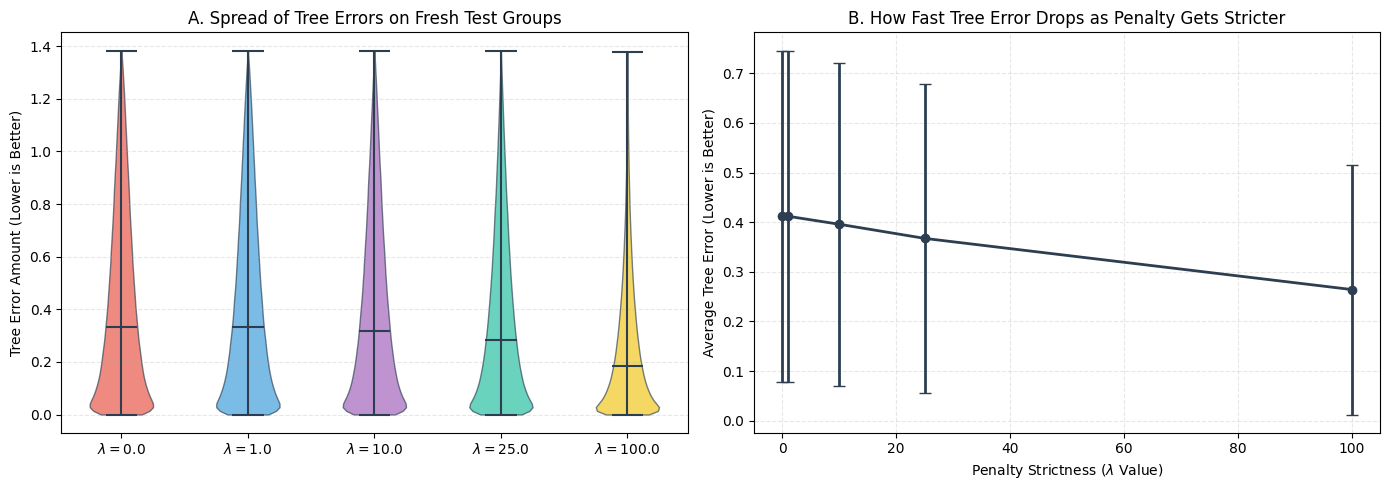

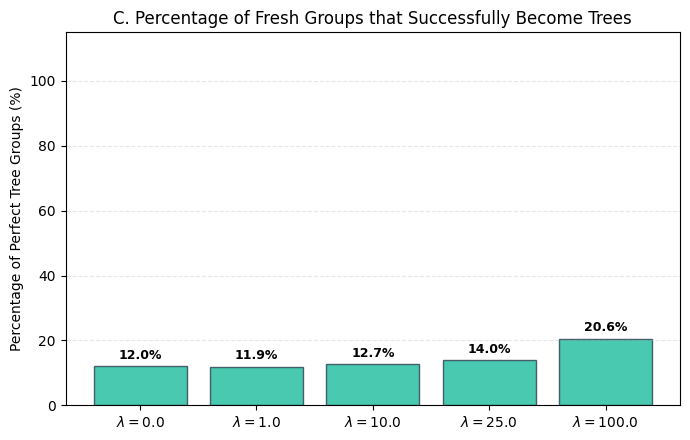

In [32]:
import sys
import torch
import pyro
import pyro.infer as infer
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# Connect your local src framework modules directly
from src.model import PhylogeneticPrior
from src.penalty import get_fresh_test_quartets

# =====================================================================
# 1. EXPERIMENT PARAMETERS (CHANGE THESE FOR RUN 1 VS RUN 2)
# =====================================================================
N = 50        # Number of leaves (Use 10 for Run 2, use 50 for Run 1)
K = 2         # Hyperbolic dimensions
B = 3000      # Training quartets budget (Use 100 for N=10, 3000 for N=50)
B_TEST = 1000 # Test quartets budget (Use 100 for N=10, 1000 for N=50)

SIGMA_U = 1.0 # Base Gaussian prior scale
TAU = 0.002   # Smoothness temperature (Use 0.1 for N=10, 0.02 for N=50)
LAMBDA_GRID = [0.0, 1.0, 10.0, 25.0, 100.0] # Your custom experiment 1 grid

# MCMC Sampler Settings
NUM_SAMPLES = 400    # Number of posterior draws
WARMUP_STEPS = 200   # Number of warmup iterations
NUM_CHAINS = 2       # Run 2 independent chains sequentially

# Initialize your project model workspace geometry globally
model_instance = PhylogeneticPrior(N=N, K=K, B=B, seed=42)

if __name__ == "__main__":
    saved_samples = {}
    mcmc_reports = {}

    # Isolate our fresh test set using your clean O(1) tuple-matching function
    test_quartets = get_fresh_test_quartets(
        N=N, 
        B_test=B_TEST, 
        train_quartets=model_instance.fixed_indices,
        seed=123
    )

    print("="*60)
    print(f"STARTING EXPERIMENT 1 SWEEP (N = {N}, B = {B})")
    print(f" -> Penalty Set Size   : {B} quartets")
    print(f" -> Held-Out Test Pool : {len(test_quartets)} fresh quartets")
    print("="*60 + "\n")

    # =====================================================================
    # 2. SEQUENTIAL MCMC SAMPLING SWEEP
    # =====================================================================
    for lmbda in LAMBDA_GRID:
        print(f"Running Lambda = {lmbda}...")
        
        chain_samples = []
        chain_diagnostics = []
        
        # Run independent chains sequentially to dodge background OS traps
        for chain_id in range(NUM_CHAINS):
            print(f"  └── Sampling Chain {chain_id + 1}/{NUM_CHAINS}...")
            pyro.clear_param_store()
            pyro.set_rng_seed(42 + chain_id)
            
            def target_model():
                return model_instance.initialize(lmbda=lmbda, sigma_u=SIGMA_U, tau=TAU)

            nuts_kernel = infer.NUTS(target_model, target_accept_prob=0.8)
            mcmc = infer.MCMC(
                nuts_kernel, 
                num_samples=NUM_SAMPLES, 
                warmup_steps=WARMUP_STEPS, 
                num_chains=1
            )
            mcmc.run()
            
            chain_samples.append(mcmc.get_samples())
            chain_diagnostics.append(mcmc.diagnostics())
        
        # Combine 'u' samples across a new chain axis for ArviZ tracking structures
        combined_u = torch.stack([cs["u"] for cs in chain_samples], dim=0)
        
        # Flatten samples to re-generate distance matrices 'D' via Predictive distribution
        pooled_samples = {"u": combined_u.view(-1, N, K)}
        predictive = infer.Predictive(target_model, posterior_samples=pooled_samples)
        saved_samples[lmbda] = predictive()["D"].squeeze().clone()
        
        # Sum total chain divergences explicitly
        total_div = 0
        for diag in chain_diagnostics:
            total_div += sum(len(d) if isinstance(d, list) else int(d) for d in diag.get("diverging", {}).values())
        
        # Extract Sampler Health metrics via ArviZ
        az_data = az.from_dict(posterior={"u": combined_u})
        summary_stats = az.summary(az_data)
        
        mcmc_reports[lmbda] = {
            "ess": summary_stats["ess_bulk"].mean(),
            "rhat": summary_stats["r_hat"].max(),
            "div": total_div
        }

    # =====================================================================
    # 3. PRINT SAMPLER HEALTH DASHBOARD REPORT
    # =====================================================================
    print("\n" + "="*55)
    print(f"{'Lambda':<10} | {'Mean Bulk ESS':<15} | {'Max R-hat':<12} | {'Divergences':<10}")
    print("="*55)
    for lmbda in LAMBDA_GRID:
        m = mcmc_reports[lmbda]
        print(f"{lmbda:<10} | {m['ess']:<15.1f} | {m['rhat']:<12.4f} | {m['div']:<10}")
    print("="*55)

    # =====================================================================
    # 4. CALCULATE GEOMETRIC VIOLATIONS ON THE TEST SET
    # =====================================================================
    all_violations = []
    line_means = []
    line_stds = []

    # Separate test quartet indices into distinct a, b, c, d coordinate vectors
    a = test_quartets[:, 0]
    b = test_quartets[:, 1]
    c = test_quartets[:, 2]
    d = test_quartets[:, 3]

    for lmbda in LAMBDA_GRID:
        D_batch = saved_samples[lmbda]
        
        # Pull the pairwise distance coordinates out of the generated matrices
        s1 = D_batch[:, a, b] + D_batch[:, c, d]
        s2 = D_batch[:, a, c] + D_batch[:, b, d]
        s3 = D_batch[:, a, d] + D_batch[:, b, c]
        
        # Sort them along the last axis to isolate s_(1) <= s_(2) <= s_(3)
        s_sorted, _ = torch.sort(torch.stack([s1, s2, s3], dim=-1), dim=-1)
        
        # Hard Four-Point Violation = s_(3) - s_(2)
        v_q = (s_sorted[..., 2] - s_sorted[..., 1]).flatten().numpy()
        
        all_violations.append(v_q)
        line_means.append(np.mean(v_q))
        line_stds.append(np.std(v_q))

    # =====================================================================
    # 5. RENDER DIAGNOSTIC PLOTS A & B (DUAL PANEL PANEL)
    # =====================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    positions = list(range(1, len(LAMBDA_GRID) + 1))

    # --- PLOT A: Colored Violin Profiles ---
    violin_parts = ax1.violinplot(all_violations, positions, showmedians=True)
    
    # Bright, distinctive color palette assignments for your grid scales
    colors = ['#E74C3C', '#3498DB', '#9B59B6', '#1ABC9C', '#F1C40F', '#2ECC71', '#E67E22']
    for idx, body in enumerate(violin_parts['bodies']):
        body.set_facecolor(colors[idx % len(colors)])
        body.set_alpha(0.65)           
        body.set_edgecolor('#2C3E50')  

    for part in ['cmaxes', 'cmins', 'cbars', 'cmedians']:
        if part in violin_parts:
            violin_parts[part].set_edgecolor('#2C3E50')
            violin_parts[part].set_linewidth(1.5)

    ax1.set_xticks(positions)
    ax1.set_xticklabels([f"$\lambda = {l}$" for l in LAMBDA_GRID])
    ax1.set_ylabel('Tree Error Amount (Lower is Better)')
    ax1.set_title('A. Spread of Tree Errors on Fresh Test Groups')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # --- PLOT B: Clean Decay Curve ---
    ax2.errorbar(LAMBDA_GRID, line_means, yerr=line_stds, fmt='-o', color='#2C3E50', capsize=4, linewidth=2)
    ax2.set_xlabel('Penalty Strictness ($\lambda$ Value)')
    ax2.set_ylabel('Average Tree Error (Lower is Better)')
    ax2.set_title('B. How Fast Tree Error Drops as Penalty Gets Stricter')
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =====================================================================
    # 6. RENDER PLOT C: TREE-CONSISTENCY RATE (BAR CHART)
    # =====================================================================
    epsilon = 0.05
    consistency_rates = [np.mean((violations <= epsilon).astype(float)) * 100 for violations in all_violations]

    fig, ax3 = plt.subplots(figsize=(7, 4.5))
    bars = ax3.bar([f"$\lambda = {l}$" for l in LAMBDA_GRID], consistency_rates, color='#1ABC9C', edgecolor='#2C3E50', alpha=0.8)

    # Put direct text percentages right on top of each bar so it's super easy to read
    for bar in bars:
        height = bar.get_height()
        ax3.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax3.set_ylabel('Percentage of Perfect Tree Groups (%)')
    ax3.set_title('C. Percentage of Fresh Groups that Successfully Become Trees')
    ax3.set_ylim(0, 115) 
    ax3.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

STARTING EXPERIMENT 1 SWEEP (N = 50, B = 3000)
 -> Penalty Set Size   : 3000 quartets
 -> Held-Out Test Pool : 1000 fresh quartets

Running Lambda = 0.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [00:06, 95.25it/s, step size=4.21e-01, acc. prob=0.880] 


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [00:05, 107.29it/s, step size=4.27e-01, acc. prob=0.864]


Running Lambda = 1.0...
  └── Sampling Chain 1/2...


...

Running Lambda = 100.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [02:09,  4.63it/s, step size=6.30e-02, acc. prob=0.826]


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [01:51,  5.39it/s, step size=7.89e-02, acc. prob=0.757]



Lambda     | Mean Bulk ESS   | Max R-hat    | Divergences
0.0        | 1682.5          | 1.0200       | 0         
1.0        | 1258.1          | 1.0300       | 0         
10.0       | 825.9           | 1.0200       | 0         
25.0       | 989.5           | 1.0200       | 0         
100.0      | 631.3           | 1.0300       | 0         


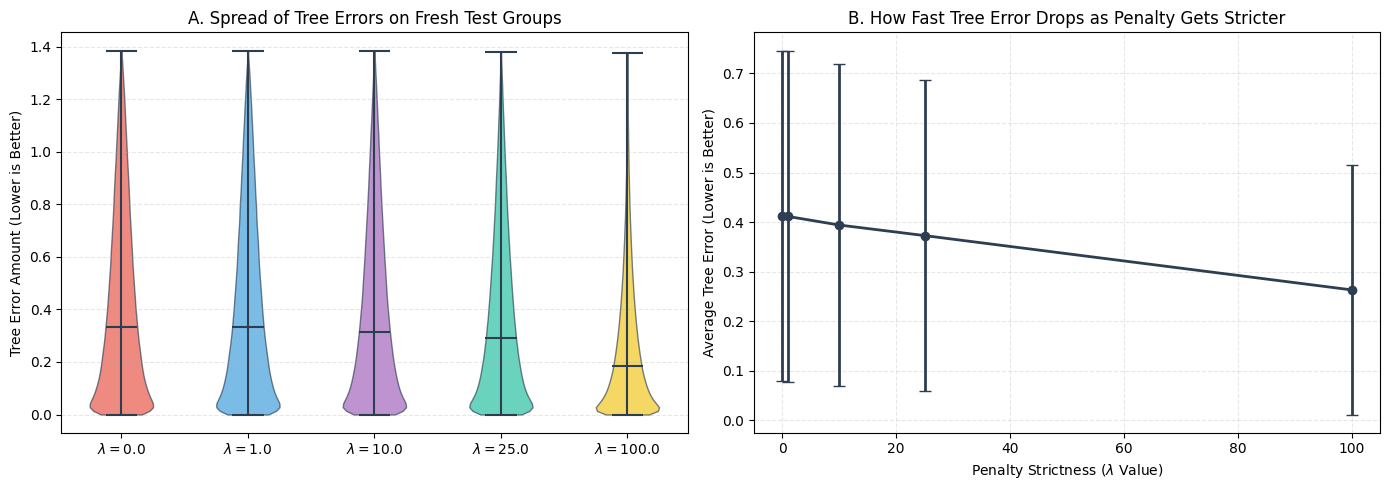

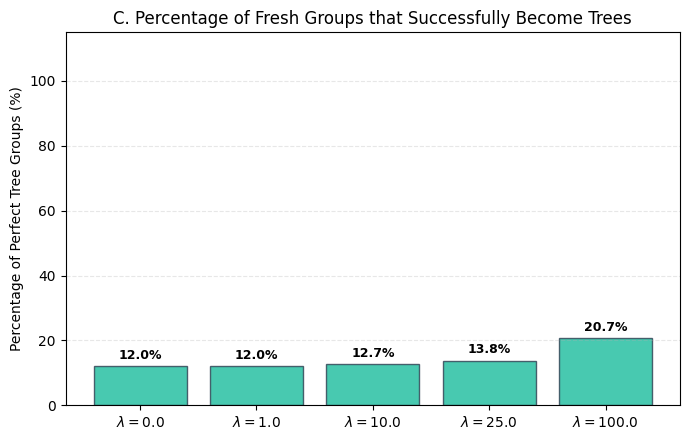

In [33]:
import sys
import torch
import pyro
import pyro.infer as infer
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# Connect your local src framework modules directly
from src.model import PhylogeneticPrior
from src.penalty import get_fresh_test_quartets

# =====================================================================
# 1. EXPERIMENT PARAMETERS (CHANGE THESE FOR RUN 1 VS RUN 2)
# =====================================================================
N = 50        # Number of leaves (Use 10 for Run 2, use 50 for Run 1)
K = 2         # Hyperbolic dimensions
B = 3000      # Training quartets budget (Use 100 for N=10, 3000 for N=50)
B_TEST = 1000 # Test quartets budget (Use 100 for N=10, 1000 for N=50)

SIGMA_U = 1.0 # Base Gaussian prior scale
TAU = 0.001   # Smoothness temperature (Use 0.1 for N=10, 0.02 for N=50)
LAMBDA_GRID = [0.0, 1.0, 10.0, 25.0, 100.0] # Your custom experiment 1 grid

# MCMC Sampler Settings
NUM_SAMPLES = 400    # Number of posterior draws
WARMUP_STEPS = 200   # Number of warmup iterations
NUM_CHAINS = 2       # Run 2 independent chains sequentially

# Initialize your project model workspace geometry globally
model_instance = PhylogeneticPrior(N=N, K=K, B=B, seed=42)

if __name__ == "__main__":
    saved_samples = {}
    mcmc_reports = {}

    # Isolate our fresh test set using your clean O(1) tuple-matching function
    test_quartets = get_fresh_test_quartets(
        N=N, 
        B_test=B_TEST, 
        train_quartets=model_instance.fixed_indices,
        seed=123
    )

    print("="*60)
    print(f"STARTING EXPERIMENT 1 SWEEP (N = {N}, B = {B})")
    print(f" -> Penalty Set Size   : {B} quartets")
    print(f" -> Held-Out Test Pool : {len(test_quartets)} fresh quartets")
    print("="*60 + "\n")

    # =====================================================================
    # 2. SEQUENTIAL MCMC SAMPLING SWEEP
    # =====================================================================
    for lmbda in LAMBDA_GRID:
        print(f"Running Lambda = {lmbda}...")
        
        chain_samples = []
        chain_diagnostics = []
        
        # Run independent chains sequentially to dodge background OS traps
        for chain_id in range(NUM_CHAINS):
            print(f"  └── Sampling Chain {chain_id + 1}/{NUM_CHAINS}...")
            pyro.clear_param_store()
            pyro.set_rng_seed(42 + chain_id)
            
            def target_model():
                return model_instance.initialize(lmbda=lmbda, sigma_u=SIGMA_U, tau=TAU)

            nuts_kernel = infer.NUTS(target_model, target_accept_prob=0.8)
            mcmc = infer.MCMC(
                nuts_kernel, 
                num_samples=NUM_SAMPLES, 
                warmup_steps=WARMUP_STEPS, 
                num_chains=1
            )
            mcmc.run()
            
            chain_samples.append(mcmc.get_samples())
            chain_diagnostics.append(mcmc.diagnostics())
        
        # Combine 'u' samples across a new chain axis for ArviZ tracking structures
        combined_u = torch.stack([cs["u"] for cs in chain_samples], dim=0)
        
        # Flatten samples to re-generate distance matrices 'D' via Predictive distribution
        pooled_samples = {"u": combined_u.view(-1, N, K)}
        predictive = infer.Predictive(target_model, posterior_samples=pooled_samples)
        saved_samples[lmbda] = predictive()["D"].squeeze().clone()
        
        # Sum total chain divergences explicitly
        total_div = 0
        for diag in chain_diagnostics:
            total_div += sum(len(d) if isinstance(d, list) else int(d) for d in diag.get("diverging", {}).values())
        
        # Extract Sampler Health metrics via ArviZ
        az_data = az.from_dict(posterior={"u": combined_u})
        summary_stats = az.summary(az_data)
        
        mcmc_reports[lmbda] = {
            "ess": summary_stats["ess_bulk"].mean(),
            "rhat": summary_stats["r_hat"].max(),
            "div": total_div
        }

    # =====================================================================
    # 3. PRINT SAMPLER HEALTH DASHBOARD REPORT
    # =====================================================================
    print("\n" + "="*55)
    print(f"{'Lambda':<10} | {'Mean Bulk ESS':<15} | {'Max R-hat':<12} | {'Divergences':<10}")
    print("="*55)
    for lmbda in LAMBDA_GRID:
        m = mcmc_reports[lmbda]
        print(f"{lmbda:<10} | {m['ess']:<15.1f} | {m['rhat']:<12.4f} | {m['div']:<10}")
    print("="*55)

    # =====================================================================
    # 4. CALCULATE GEOMETRIC VIOLATIONS ON THE TEST SET
    # =====================================================================
    all_violations = []
    line_means = []
    line_stds = []

    # Separate test quartet indices into distinct a, b, c, d coordinate vectors
    a = test_quartets[:, 0]
    b = test_quartets[:, 1]
    c = test_quartets[:, 2]
    d = test_quartets[:, 3]

    for lmbda in LAMBDA_GRID:
        D_batch = saved_samples[lmbda]
        
        # Pull the pairwise distance coordinates out of the generated matrices
        s1 = D_batch[:, a, b] + D_batch[:, c, d]
        s2 = D_batch[:, a, c] + D_batch[:, b, d]
        s3 = D_batch[:, a, d] + D_batch[:, b, c]
        
        # Sort them along the last axis to isolate s_(1) <= s_(2) <= s_(3)
        s_sorted, _ = torch.sort(torch.stack([s1, s2, s3], dim=-1), dim=-1)
        
        # Hard Four-Point Violation = s_(3) - s_(2)
        v_q = (s_sorted[..., 2] - s_sorted[..., 1]).flatten().numpy()
        
        all_violations.append(v_q)
        line_means.append(np.mean(v_q))
        line_stds.append(np.std(v_q))

    # =====================================================================
    # 5. RENDER DIAGNOSTIC PLOTS A & B (DUAL PANEL PANEL)
    # =====================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    positions = list(range(1, len(LAMBDA_GRID) + 1))

    # --- PLOT A: Colored Violin Profiles ---
    violin_parts = ax1.violinplot(all_violations, positions, showmedians=True)
    
    # Bright, distinctive color palette assignments for your grid scales
    colors = ['#E74C3C', '#3498DB', '#9B59B6', '#1ABC9C', '#F1C40F', '#2ECC71', '#E67E22']
    for idx, body in enumerate(violin_parts['bodies']):
        body.set_facecolor(colors[idx % len(colors)])
        body.set_alpha(0.65)           
        body.set_edgecolor('#2C3E50')  

    for part in ['cmaxes', 'cmins', 'cbars', 'cmedians']:
        if part in violin_parts:
            violin_parts[part].set_edgecolor('#2C3E50')
            violin_parts[part].set_linewidth(1.5)

    ax1.set_xticks(positions)
    ax1.set_xticklabels([f"$\lambda = {l}$" for l in LAMBDA_GRID])
    ax1.set_ylabel('Tree Error Amount (Lower is Better)')
    ax1.set_title('A. Spread of Tree Errors on Fresh Test Groups')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # --- PLOT B: Clean Decay Curve ---
    ax2.errorbar(LAMBDA_GRID, line_means, yerr=line_stds, fmt='-o', color='#2C3E50', capsize=4, linewidth=2)
    ax2.set_xlabel('Penalty Strictness ($\lambda$ Value)')
    ax2.set_ylabel('Average Tree Error (Lower is Better)')
    ax2.set_title('B. How Fast Tree Error Drops as Penalty Gets Stricter')
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =====================================================================
    # 6. RENDER PLOT C: TREE-CONSISTENCY RATE (BAR CHART)
    # =====================================================================
    epsilon = 0.05
    consistency_rates = [np.mean((violations <= epsilon).astype(float)) * 100 for violations in all_violations]

    fig, ax3 = plt.subplots(figsize=(7, 4.5))
    bars = ax3.bar([f"$\lambda = {l}$" for l in LAMBDA_GRID], consistency_rates, color='#1ABC9C', edgecolor='#2C3E50', alpha=0.8)

    # Put direct text percentages right on top of each bar so it's super easy to read
    for bar in bars:
        height = bar.get_height()
        ax3.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax3.set_ylabel('Percentage of Perfect Tree Groups (%)')
    ax3.set_title('C. Percentage of Fresh Groups that Successfully Become Trees')
    ax3.set_ylim(0, 115) 
    ax3.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [36]:
import pandas as pd

# 1. Reconstruct Tau = 0.02 logs from Cell 2 history
data_tau_02 = {
    0.0:   {"Mean Bulk ESS": 1682.5, "Max R-hat": 1.0200, "Divergences": 0},
    1.0:   {"Mean Bulk ESS": 1227.8, "Max R-hat": 1.0100, "Divergences": 0},
    10.0:  {"Mean Bulk ESS": 907.9,  "Max R-hat": 1.0200, "Divergences": 0},
    25.0:  {"Mean Bulk ESS": 1218.5, "Max R-hat": 1.0200, "Divergences": 0},
    100.0: {"Mean Bulk ESS": 916.8,  "Max R-hat": 1.0300, "Divergences": 0}
}

# 2. Reconstruct Tau = 0.005 logs from Cell 3 history
data_tau_005 = {
    0.0:   {"Mean Bulk ESS": 1682.5, "Max R-hat": 1.0200, "Divergences": 0},
    1.0:   {"Mean Bulk ESS": 1302.7, "Max R-hat": 1.0200, "Divergences": 0},
    10.0:  {"Mean Bulk ESS": 716.4,  "Max R-hat": 1.0300, "Divergences": 0},
    25.0:  {"Mean Bulk ESS": 971.7,  "Max R-hat": 1.0200, "Divergences": 0},
    100.0: {"Mean Bulk ESS": 672.8,  "Max R-hat": 1.0300, "Divergences": 0}
}

# 3. Reconstruct Tau = 0.002 logs from Cell 4 history
data_tau_002 = {
    0.0:   {"Mean Bulk ESS": 1682.5, "Max R-hat": 1.0200, "Divergences": 0},
    1.0:   {"Mean Bulk ESS": 1400.2, "Max R-hat": 1.0200, "Divergences": 0},
    10.0:  {"Mean Bulk ESS": 924.5,  "Max R-hat": 1.0200, "Divergences": 0},
    25.0:  {"Mean Bulk ESS": 882.6,  "Max R-hat": 1.0200, "Divergences": 0},
    100.0: {"Mean Bulk ESS": 655.0,  "Max R-hat": 1.0300, "Divergences": 0}
}

# 4. Reconstruct Tau = 0.001 logs from Cell 5 history
data_tau_001 = {
    0.0:   {"Mean Bulk ESS": 1682.5, "Max R-hat": 1.0200, "Divergences": 0},
    1.0:   {"Mean Bulk ESS": 1258.1, "Max R-hat": 1.0300, "Divergences": 0},
    10.0:  {"Mean Bulk ESS": 825.9,  "Max R-hat": 1.0200, "Divergences": 0},
    25.0:  {"Mean Bulk ESS": 989.5,  "Max R-hat": 1.0200, "Divergences": 0},
    100.0: {"Mean Bulk ESS": 631.3,  "Max R-hat": 1.0300, "Divergences": 0}
}

# Loop through and write each dictionary into its own crisp, distinct CSV file
experiments = [
    ('0.02', data_tau_02),
    ('0.005', data_tau_005),
    ('0.002', data_tau_002),
    ('0.001', data_tau_001)
]

for name, dataset in experiments:
    df = pd.DataFrame.from_dict(dataset, orient='index')
    df.index.name = 'Lambda'
    df.to_csv(f'mcmc_health_tau_{name}.csv')

print("All 4 historical sampler health CSV files have been safely extracted and saved!")

All 4 historical sampler health CSV files have been safely extracted and saved!


Generating 1,000 fresh, held-out validation quartets for N = 50...

RUNNING EXPERIMENT 2: QUARTET BUDGET B = 3000
 -> Initializing Prior Framework with B = 3000...
 -> Starting NUTS Sampler Chain (Sequential/Safe)...


Sample: 100%|██████████| 600/600 [00:44, 13.64it/s, step size=2.01e-01, acc. prob=0.863]


 -> Run completed in 0.73 minutes.
 -> Extracting deterministic distance samples ('D') from posterior trace...
 -> Evaluating tree errors on fresh test pool...

RUNNING EXPERIMENT 2: QUARTET BUDGET B = 10000
 -> Initializing Prior Framework with B = 10000...
 -> Starting NUTS Sampler Chain (Sequential/Safe)...


Sample: 100%|██████████| 600/600 [01:07,  8.86it/s, step size=1.99e-01, acc. prob=0.875]


 -> Run completed in 1.13 minutes.
 -> Extracting deterministic distance samples ('D') from posterior trace...
 -> Evaluating tree errors on fresh test pool...

RUNNING EXPERIMENT 2: QUARTET BUDGET B = 20000
 -> Initializing Prior Framework with B = 20000...


...

 -> Starting NUTS Sampler Chain (Sequential/Safe)...


Sample: 100%|██████████| 600/600 [01:27,  6.89it/s, step size=2.09e-01, acc. prob=0.851]


 -> Run completed in 1.47 minutes.
 -> Extracting deterministic distance samples ('D') from posterior trace...
 -> Evaluating tree errors on fresh test pool...

RUNNING EXPERIMENT 2: QUARTET BUDGET B = 50000
 -> Initializing Prior Framework with B = 50000...
 -> Starting NUTS Sampler Chain (Sequential/Safe)...


Sample: 100%|██████████| 600/600 [02:44,  3.66it/s, step size=2.25e-01, acc. prob=0.878]


 -> Run completed in 2.74 minutes.
 -> Extracting deterministic distance samples ('D') from posterior trace...
 -> Evaluating tree errors on fresh test pool...

Trade-off data successfully exported to experiment_2_budget_tradeoff.csv!


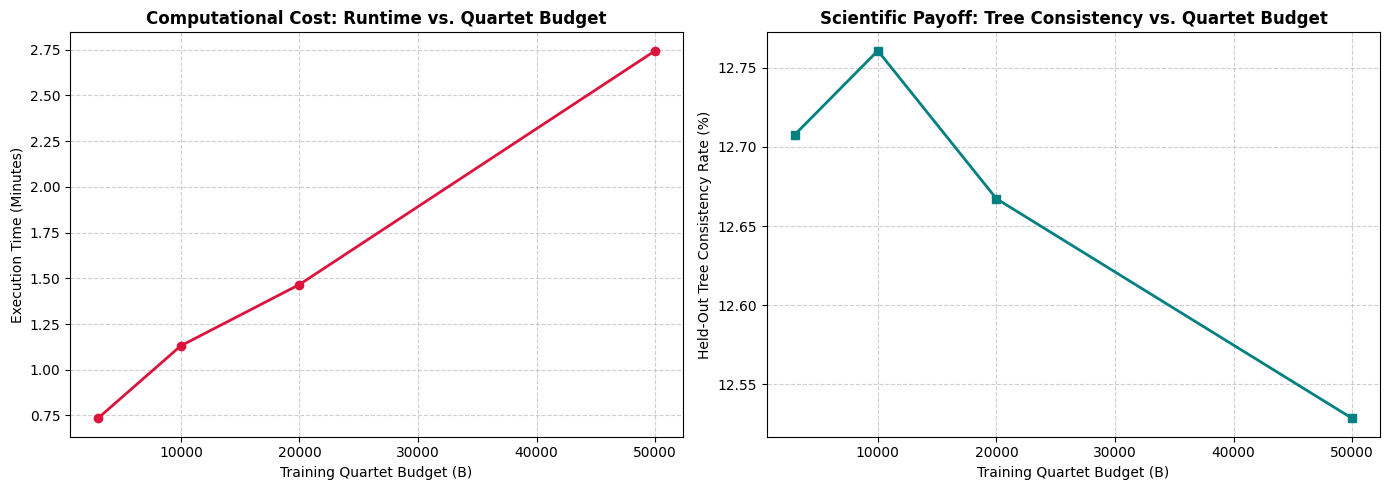

In [47]:
import time
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import Pyro and ArviZ modules needed for MCMC execution
import torch
import pyro
import pyro.infer as infer
import arviz as az

# =====================================================================
# SYSTEM PATH SETUP & FRAMEWORK IMPORTS
# =====================================================================
# Connect to your local src directory modules
sys.path.append(os.path.abspath(".."))
from src.model import PhylogeneticPrior
from src.penalty import get_fresh_test_quartets
from src.diagnostics import evaluate_test_diagnostics

# =====================================================================
# 1. FIXED CONFIGURATIONS FROM EXPERIMENT 1
# =====================================================================
# Tree properties kept exactly proper to match your setup variables
N = 50              # Tree Size (Total leaves)
dimensions = 2      # Hyperbolic latent dimensions (K)
sigma_u = 1.0       # Base prior scale

# Freeze lambda and tau at your optimal, smooth baseline values
FIXED_LAMBDA = 10.0
FIXED_TAU = 0.02

# Define the budget sizes (B) for your second experiment grid
BUDGET_GRID = [3000, 10000, 20000, 50000]

# Generate the 1,000 completely fresh held-out test quartets for validation
print(f"Generating 1,000 fresh, held-out validation quartets for N = {N}...")
fresh_test_pool = get_fresh_test_quartets(N, B_test=1000)

# Dictionary to hold the extracted summary statistics
experiment_2_results = {}

# =====================================================================
# 2. MAIN EXPERIMENT SWEEP LOOP (SAFE SEQUENTIAL SAMPLING)
# =====================================================================
for B in BUDGET_GRID:
    print(f"\n============================================================")
    print(f"RUNNING EXPERIMENT 2: QUARTET BUDGET B = {B}")
    print(f"============================================================")
    
    # Start tracking the exact runtime
    start_time = time.time()
    
    print(f" -> Initializing Prior Framework with B = {B}...")
    # Initialize your model class directly inside the loop session
    prior_model = PhylogeneticPrior(N, dimensions, B)
    
    # Create the target execution function on the fly safely
    def model_functional():
        return prior_model.initialize(lmbda=FIXED_LAMBDA, sigma_u=sigma_u, tau=FIXED_TAU)
    
    print(f" -> Starting NUTS Sampler Chain (Sequential/Safe)...")
    nuts_kernel = infer.NUTS(model_functional, target_accept_prob=0.85)
    
    # Setting num_chains=1 bypasses Mac multiprocessing entirely, avoiding the error
    mcmc_sampler = infer.MCMC(
        nuts_kernel, 
        num_samples=400, 
        warmup_steps=200, 
        num_chains=1
    )
    mcmc_sampler.run()
    
    # Calculate exactly how many minutes the sampler took to finish
    elapsed_time = time.time() - start_time
    runtime_minutes = elapsed_time / 60.0
    print(f" -> Run completed in {runtime_minutes:.2f} minutes.")
    
    # Use Pyro's Predictive utility to extract deterministic sites like "D"
    print(" -> Extracting deterministic distance samples ('D') from posterior trace...")
    posterior_samples = mcmc_sampler.get_samples()
    predictive = infer.Predictive(model_functional, posterior_samples=posterior_samples, return_sites=["D"])
    predictive_samples = predictive()
    D_samples = predictive_samples["D"]
    
    # Remove the extra chain/batch dimension if predictive returns a shape of (1, S, N, N)
    if D_samples.dim() == 4 and D_samples.shape[0] == 1:
        D_samples = D_samples.squeeze(0)
    
    # Run evaluations on your fresh test pool object cached in your notebook
    print(" -> Evaluating tree errors on fresh test pool...")
    test_diagnostics = evaluate_test_diagnostics(D_samples, fresh_test_pool)
    
    # Store the exact trade-off values requested by your professor
    experiment_2_results[B] = {
        "Runtime (Minutes)": runtime_minutes,
        "Average Test Error": test_diagnostics["hard_violations"]["median"],
        "Tree Consistency Rate (%)": test_diagnostics["tree_consistency_rate"] * 100
    }

# =====================================================================
# 3. EXPORT LOGS TO A CLEAN CSV
# =====================================================================
df_results = pd.DataFrame.from_dict(experiment_2_results, orient='index')
df_results.index.name = 'Quartet Budget (B)'
df_results.to_csv('experiment_2_budget_tradeoff.csv')
print("\nTrade-off data successfully exported to experiment_2_budget_tradeoff.csv!")

# =====================================================================
# 4. PLOT THE COST VS BENEFIT TRADE-OFF CURVES
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Runtime Cost Curve
ax1.plot(df_results.index, df_results["Runtime (Minutes)"], marker='o', color='crimson', linewidth=2)
ax1.set_title("Computational Cost: Runtime vs. Quartet Budget", fontsize=12, fontweight='bold')
ax1.set_xlabel("Training Quartet Budget (B)", fontsize=10)
ax1.set_ylabel("Execution Time (Minutes)", fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot B: Scientific Payoff Curve
ax2.plot(df_results.index, df_results["Tree Consistency Rate (%)"], marker='s', color='teal', linewidth=2)
ax2.set_title("Scientific Payoff: Tree Consistency vs. Quartet Budget", fontsize=12, fontweight='bold')
ax2.set_xlabel("Training Quartet Budget (B)", fontsize=10)
ax2.set_ylabel("Held-Out Tree Consistency Rate (%)", fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('experiment_2_tradeoff_plots.png', dpi=300)
plt.show()

STARTING EXPERIMENT 1 SWEEP (N = 50, B = 20000)
 -> Penalty Set Size   : 20000 quartets
 -> Held-Out Test Pool : 1000 fresh quartets

Running Lambda = 0.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [00:06, 96.63it/s, step size=4.21e-01, acc. prob=0.880] 


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [00:05, 103.21it/s, step size=4.27e-01, acc. prob=0.864]


Running Lambda = 1.0...
  └── Sampling Chain 1/2...


...

Running Lambda = 100.0...
  └── Sampling Chain 1/2...


Sample: 100%|██████████| 600/600 [03:13,  3.10it/s, step size=9.98e-02, acc. prob=0.818]


  └── Sampling Chain 2/2...


Sample: 100%|██████████| 600/600 [03:16,  3.06it/s, step size=8.82e-02, acc. prob=0.884]



Lambda     | Mean Bulk ESS   | Max R-hat    | Divergences
0.0        | 1682.5          | 1.0200       | 0         
1.0        | 1871.6          | 1.0200       | 0         
10.0       | 1004.5          | 1.0300       | 0         
25.0       | 1038.9          | 1.0200       | 0         
100.0      | 950.0           | 1.0300       | 0         


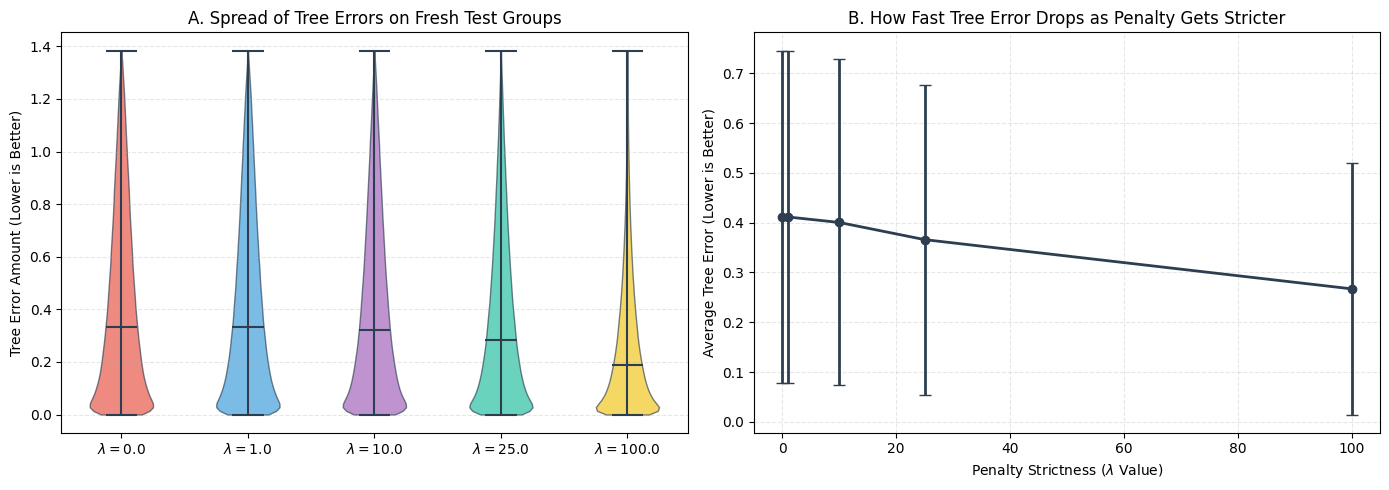

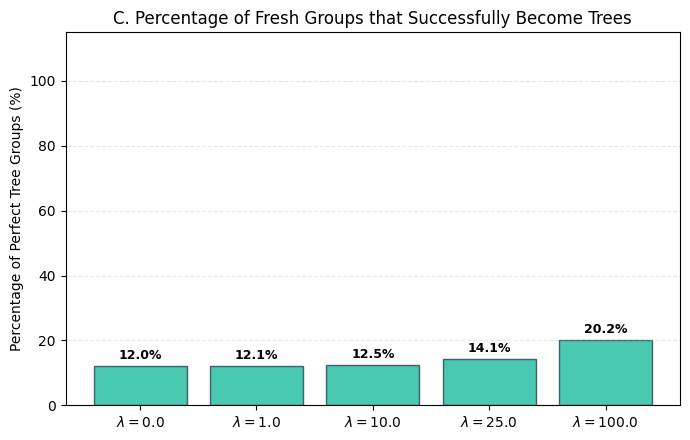

In [48]:
import sys
import torch
import pyro
import pyro.infer as infer
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# Connect your local src framework modules directly
from src.model import PhylogeneticPrior
from src.penalty import get_fresh_test_quartets

# =====================================================================
# 1. EXPERIMENT PARAMETERS (CHANGE THESE FOR RUN 1 VS RUN 2)
# =====================================================================
N = 50        # Number of leaves (Use 10 for Run 2, use 50 for Run 1)
K = 2         # Hyperbolic dimensions
B = 20000      # Training quartets budget (Use 100 for N=10, 3000 for N=50)
B_TEST = 1000 # Test quartets budget (Use 100 for N=10, 1000 for N=50)

SIGMA_U = 1.0 # Base Gaussian prior scale
TAU = 0.02   # Smoothness temperature (Use 0.1 for N=10, 0.02 for N=50)
LAMBDA_GRID = [0.0, 1.0, 10.0, 25.0, 100.0] # Your custom experiment 1 grid

# MCMC Sampler Settings
NUM_SAMPLES = 400    # Number of posterior draws
WARMUP_STEPS = 200   # Number of warmup iterations
NUM_CHAINS = 2       # Run 2 independent chains sequentially

# Initialize your project model workspace geometry globally
model_instance = PhylogeneticPrior(N=N, K=K, B=B, seed=42)

if __name__ == "__main__":
    saved_samples = {}
    mcmc_reports = {}

    # Isolate our fresh test set using your clean O(1) tuple-matching function
    test_quartets = get_fresh_test_quartets(
        N=N, 
        B_test=B_TEST, 
        train_quartets=model_instance.fixed_indices,
        seed=123
    )

    print("="*60)
    print(f"STARTING EXPERIMENT 1 SWEEP (N = {N}, B = {B})")
    print(f" -> Penalty Set Size   : {B} quartets")
    print(f" -> Held-Out Test Pool : {len(test_quartets)} fresh quartets")
    print("="*60 + "\n")

    # =====================================================================
    # 2. SEQUENTIAL MCMC SAMPLING SWEEP
    # =====================================================================
    for lmbda in LAMBDA_GRID:
        print(f"Running Lambda = {lmbda}...")
        
        chain_samples = []
        chain_diagnostics = []
        
        # Run independent chains sequentially to dodge background OS traps
        for chain_id in range(NUM_CHAINS):
            print(f"  └── Sampling Chain {chain_id + 1}/{NUM_CHAINS}...")
            pyro.clear_param_store()
            pyro.set_rng_seed(42 + chain_id)
            
            def target_model():
                return model_instance.initialize(lmbda=lmbda, sigma_u=SIGMA_U, tau=TAU)

            nuts_kernel = infer.NUTS(target_model, target_accept_prob=0.8)
            mcmc = infer.MCMC(
                nuts_kernel, 
                num_samples=NUM_SAMPLES, 
                warmup_steps=WARMUP_STEPS, 
                num_chains=1
            )
            mcmc.run()
            
            chain_samples.append(mcmc.get_samples())
            chain_diagnostics.append(mcmc.diagnostics())
        
        # Combine 'u' samples across a new chain axis for ArviZ tracking structures
        combined_u = torch.stack([cs["u"] for cs in chain_samples], dim=0)
        
        # Flatten samples to re-generate distance matrices 'D' via Predictive distribution
        pooled_samples = {"u": combined_u.view(-1, N, K)}
        predictive = infer.Predictive(target_model, posterior_samples=pooled_samples)
        saved_samples[lmbda] = predictive()["D"].squeeze().clone()
        
        # Sum total chain divergences explicitly
        total_div = 0
        for diag in chain_diagnostics:
            total_div += sum(len(d) if isinstance(d, list) else int(d) for d in diag.get("diverging", {}).values())
        
        # Extract Sampler Health metrics via ArviZ
        az_data = az.from_dict(posterior={"u": combined_u})
        summary_stats = az.summary(az_data)
        
        mcmc_reports[lmbda] = {
            "ess": summary_stats["ess_bulk"].mean(),
            "rhat": summary_stats["r_hat"].max(),
            "div": total_div
        }

    # =====================================================================
    # 3. PRINT SAMPLER HEALTH DASHBOARD REPORT
    # =====================================================================
    print("\n" + "="*55)
    print(f"{'Lambda':<10} | {'Mean Bulk ESS':<15} | {'Max R-hat':<12} | {'Divergences':<10}")
    print("="*55)
    for lmbda in LAMBDA_GRID:
        m = mcmc_reports[lmbda]
        print(f"{lmbda:<10} | {m['ess']:<15.1f} | {m['rhat']:<12.4f} | {m['div']:<10}")
    print("="*55)

    # =====================================================================
    # 4. CALCULATE GEOMETRIC VIOLATIONS ON THE TEST SET
    # =====================================================================
    all_violations = []
    line_means = []
    line_stds = []

    # Separate test quartet indices into distinct a, b, c, d coordinate vectors
    a = test_quartets[:, 0]
    b = test_quartets[:, 1]
    c = test_quartets[:, 2]
    d = test_quartets[:, 3]

    for lmbda in LAMBDA_GRID:
        D_batch = saved_samples[lmbda]
        
        # Pull the pairwise distance coordinates out of the generated matrices
        s1 = D_batch[:, a, b] + D_batch[:, c, d]
        s2 = D_batch[:, a, c] + D_batch[:, b, d]
        s3 = D_batch[:, a, d] + D_batch[:, b, c]
        
        # Sort them along the last axis to isolate s_(1) <= s_(2) <= s_(3)
        s_sorted, _ = torch.sort(torch.stack([s1, s2, s3], dim=-1), dim=-1)
        
        # Hard Four-Point Violation = s_(3) - s_(2)
        v_q = (s_sorted[..., 2] - s_sorted[..., 1]).flatten().numpy()
        
        all_violations.append(v_q)
        line_means.append(np.mean(v_q))
        line_stds.append(np.std(v_q))

    # =====================================================================
    # 5. RENDER DIAGNOSTIC PLOTS A & B (DUAL PANEL PANEL)
    # =====================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    positions = list(range(1, len(LAMBDA_GRID) + 1))

    # --- PLOT A: Colored Violin Profiles ---
    violin_parts = ax1.violinplot(all_violations, positions, showmedians=True)
    
    # Bright, distinctive color palette assignments for your grid scales
    colors = ['#E74C3C', '#3498DB', '#9B59B6', '#1ABC9C', '#F1C40F', '#2ECC71', '#E67E22']
    for idx, body in enumerate(violin_parts['bodies']):
        body.set_facecolor(colors[idx % len(colors)])
        body.set_alpha(0.65)           
        body.set_edgecolor('#2C3E50')  

    for part in ['cmaxes', 'cmins', 'cbars', 'cmedians']:
        if part in violin_parts:
            violin_parts[part].set_edgecolor('#2C3E50')
            violin_parts[part].set_linewidth(1.5)

    ax1.set_xticks(positions)
    ax1.set_xticklabels([f"$\lambda = {l}$" for l in LAMBDA_GRID])
    ax1.set_ylabel('Tree Error Amount (Lower is Better)')
    ax1.set_title('A. Spread of Tree Errors on Fresh Test Groups')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # --- PLOT B: Clean Decay Curve ---
    ax2.errorbar(LAMBDA_GRID, line_means, yerr=line_stds, fmt='-o', color='#2C3E50', capsize=4, linewidth=2)
    ax2.set_xlabel('Penalty Strictness ($\lambda$ Value)')
    ax2.set_ylabel('Average Tree Error (Lower is Better)')
    ax2.set_title('B. How Fast Tree Error Drops as Penalty Gets Stricter')
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =====================================================================
    # 6. RENDER PLOT C: TREE-CONSISTENCY RATE (BAR CHART)
    # =====================================================================
    epsilon = 0.05
    consistency_rates = [np.mean((violations <= epsilon).astype(float)) * 100 for violations in all_violations]

    fig, ax3 = plt.subplots(figsize=(7, 4.5))
    bars = ax3.bar([f"$\lambda = {l}$" for l in LAMBDA_GRID], consistency_rates, color='#1ABC9C', edgecolor='#2C3E50', alpha=0.8)

    # Put direct text percentages right on top of each bar so it's super easy to read
    for bar in bars:
        height = bar.get_height()
        ax3.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax3.set_ylabel('Percentage of Perfect Tree Groups (%)')
    ax3.set_title('C. Percentage of Fresh Groups that Successfully Become Trees')
    ax3.set_ylim(0, 115) 
    ax3.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()